In [1]:
!pip install opencv-python scikit-learn matplotlib joblib

In [2]:
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.datasets import fetch_olivetti_faces

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
digits = load_digits()

X_digits = digits.images
y_digits = digits.target

print(X_digits.shape)

(1797, 8, 8)


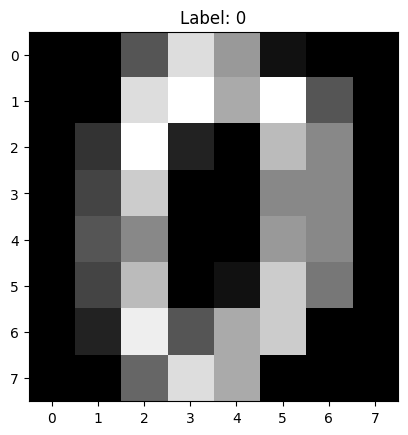

In [4]:
plt.imshow(X_digits[0], cmap='gray')

plt.title(f"Label: {y_digits[0]}")

plt.show()

In [5]:
X_digits = X_digits.reshape((len(X_digits), -1))

print(X_digits.shape)

(1797, 64)


Generate Alphabet Images

In [23]:
import string
import random
alphabet_images = []
alphabet_labels = []

for letter in string.ascii_uppercase:


    for i in range(200):


        img = np.zeros((120,120), dtype=np.uint8)

        font_scale = random.uniform(2, 3)

        thickness = random.randint(3,6)

        x = random.randint(10,25)

        y = random.randint(70,100)

        fonts = [
            cv2.FONT_HERSHEY_SIMPLEX,
            cv2.FONT_HERSHEY_COMPLEX,
            cv2.FONT_HERSHEY_DUPLEX,
            cv2.FONT_HERSHEY_TRIPLEX
        ]

        font = random.choice(fonts)


        cv2.putText(
            img,
            letter,
            (x,y),
            font,
            font_scale,
            (255),
            thickness
        )


        angle = random.randint(-5,5)

        M = cv2.getRotationMatrix2D((60,60), angle, 1)

        img = cv2.warpAffine(img, M, (120,120))


        noise = np.random.randint(0,10,(120,120), dtype=np.uint8)

        img = cv2.add(img, noise)


        img = cv2.GaussianBlur(img, (3,3), 0)


        img = cv2.resize(img, (64,64))


        img = img / 255.0


        alphabet_images.append(img.flatten())


        alphabet_labels.append(letter)


X_alpha = np.array(alphabet_images)

y_alpha = np.array(alphabet_labels)

print("Dataset Shape:", X_alpha.shape)

Dataset Shape: (5200, 4096)


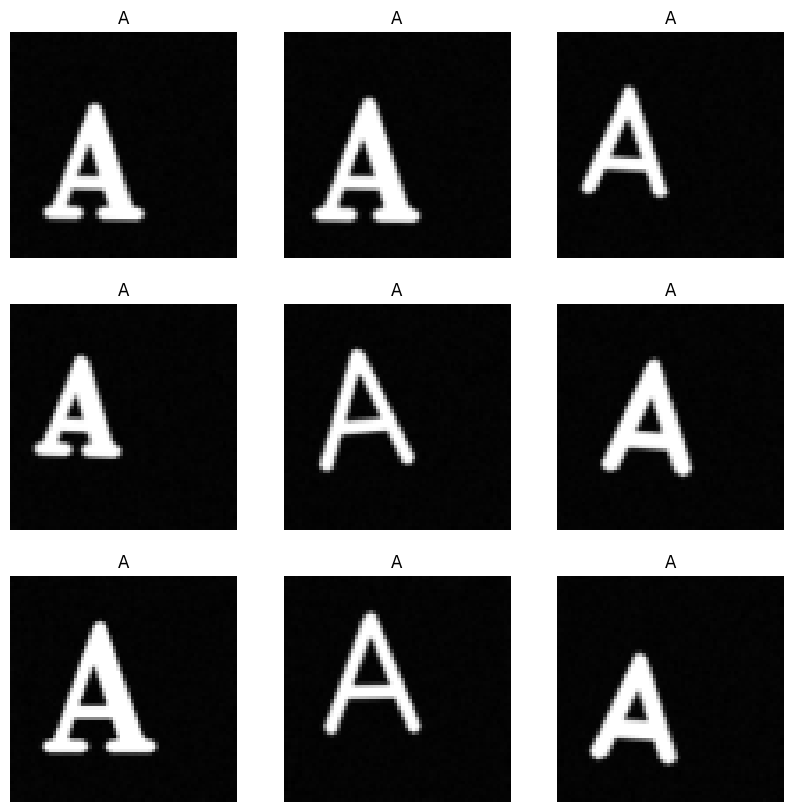

In [24]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_alpha[i].reshape(64,64), cmap='gray')

    plt.title(y_alpha[i])

    plt.axis('off')

plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_alpha,
    y_alpha,
    test_size=0.2,
    random_state=42,
    stratify=y_alpha
)

In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [27]:
model = SVC(kernel='linear')

model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Accuracy: 0.7615384615384615

Classification Report:

              precision    recall  f1-score   support

           A       0.97      0.93      0.95        40
           B       0.55      0.57      0.56        40
           C       0.81      0.85      0.83        40
           D       0.70      0.75      0.72        40
           E       0.82      0.70      0.76        40
           F       0.71      0.72      0.72        40
           G       0.56      0.68      0.61        40
           H       0.61      0.68      0.64        40
           I       0.63      0.97      0.76        40
           J       0.86      0.90      0.88        40
           K       0.82      0.78      0.79        40
           L       0.93      0.93      0.93        40
           M       0.97      0.75      0.85        40
           N       0.72      0.72      0.72        40
           O       0.84      0.65      0.73        40
           P       0.87      0.82      0.85        40
           Q       0.74   

In [28]:
test_img = np.zeros((120,120), dtype=np.uint8)

cv2.putText(
    test_img,
    'A',
    (20,90),
    cv2.FONT_HERSHEY_SIMPLEX,
    2.5,
    (255),
    5
)

test_img = cv2.GaussianBlur(test_img, (3,3), 0)

test_img = cv2.resize(test_img, (64,64))

test_img = test_img / 255.0

test_flat = test_img.flatten().reshape(1,-1)

test_flat = scaler.transform(test_flat)

prediction = model.predict(test_flat)

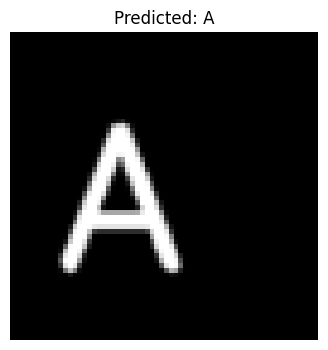


Predicted Alphabet: A


In [29]:
plt.figure(figsize=(4,4))

plt.imshow(test_img, cmap='gray')

plt.title(f"Predicted: {prediction[0]}")

plt.axis('off')

plt.show()

print("\nPredicted Alphabet:", prediction[0])

FACE RECOGNITION

In [8]:
faces = fetch_olivetti_faces()

X_faces = faces.images
y_faces = faces.target

print(X_faces.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 64, 64)


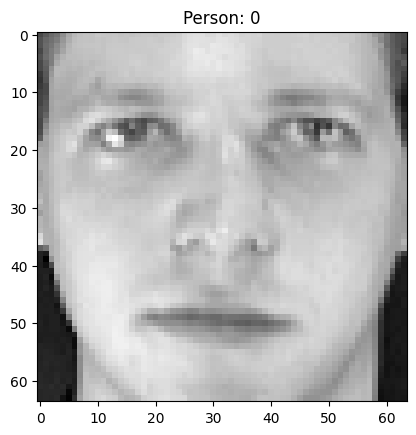

In [9]:
plt.imshow(X_faces[0], cmap='gray')

plt.title(f"Person: {y_faces[0]}")

plt.show()

In [10]:
X_faces = X_faces.reshape((len(X_faces), -1))

print(X_faces.shape)

(400, 4096)


In [11]:
def train_svm(X, y, title):


    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )


    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)


    model = SVC(
        kernel='rbf',
        C=1,
        gamma='scale'
    )


    model.fit(X_train, y_train)


    predictions = model.predict(X_test)


    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(f"\n{title} Accuracy:", accuracy)

    print("\nClassification Report:\n")

    print(classification_report(
        y_test,
        predictions
    ))

    return model, scaler

TRAIN ALL MODELS

In [12]:
digit_model, digit_scaler = train_svm(
    X_digits,
    y_digits,
    "Digit Recognition"
)


Digit Recognition Accuracy: 0.9805555555555555

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       0.96      1.00      0.98        46
           5       0.96      0.98      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



In [36]:
joblib.dump(digit_scaler, "digit_scaler.pkl")

['digit_scaler.pkl']

In [31]:
alpha_model, alpha_scaler = train_svm(
    X_alpha,
    y_alpha,
    "Alphabet Recognition"
)


Alphabet Recognition Accuracy: 0.7355769230769231

Classification Report:

              precision    recall  f1-score   support

           A       1.00      0.84      0.91        50
           B       0.55      0.54      0.54        41
           C       0.84      0.82      0.83        45
           D       0.93      0.58      0.71        45
           E       0.96      0.61      0.74        38
           F       0.64      0.73      0.68        37
           G       0.53      0.79      0.63        38
           H       0.77      0.53      0.63        45
           I       0.63      0.88      0.73        41
           J       0.84      0.86      0.85        37
           K       0.65      0.92      0.76        26
           L       0.88      0.74      0.81        39
           M       0.49      0.86      0.63        37
           N       0.85      0.79      0.81        42
           O       0.63      0.68      0.65        40
           P       0.79      0.84      0.82        37
     

In [39]:
joblib.dump(alpha_scaler, "alpha_scaler.pkl")

['alpha_scaler.pkl']

In [32]:
face_model, face_scaler = train_svm(
    X_faces,
    y_faces,
    "Face Recognition"
)


Face Recognition Accuracy: 0.95

Classification Report:

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       0.67      1.00      0.80         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
joblib.dump(face_scaler, "face_scaler.pkl")

['face_scaler.pkl']

In [33]:
joblib.dump(digit_model, "digit_model.pkl")

joblib.dump(alpha_model, "alphabet_model.pkl")

joblib.dump(face_model, "face_model.pkl")

print("All models saved successfully!")

All models saved successfully!


Streamlite one

In [34]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 72.3 MB/s eta 0:00:00


In [45]:
import os

print(os.listdir())

['.config', 'face_scaler.pkl', 'digit_scaler.pkl', 'alpha_scaler.pkl', 'digit_model.pkl', 'alphabet_model.pkl', 'face_model.pkl', 'sample_data']


In [46]:
import streamlit as st
import cv2
import numpy as np
import joblib
from PIL import Image

digit_model = joblib.load("digit_model.pkl")

alphabet_model = joblib.load("alphabet_model.pkl")

face_model = joblib.load("face_model.pkl")

digit_scaler = joblib.load("digit_scaler.pkl")

alphabet_scaler = joblib.load("alpha_scaler.pkl")

face_scaler = joblib.load("face_scaler.pkl")


st.set_page_config(
    page_title="AI Multi Recognition System",
    layout="centered"
)

st.title("AI Multi Recognition System")

st.write(
    """
    This application can perform:

    • Digit Recognition

    • Alphabet Recognition

    • Face Recognition
    """
)

option = st.sidebar.selectbox(
    "Choose Recognition Type",
    (
        "Digit Recognition",
        "Alphabet Recognition",
        "Face Recognition"
    )
)

uploaded_file = st.file_uploader(
    "Upload an Image",
    type=["png", "jpg", "jpeg"]
)

if uploaded_file is not None:


    image = Image.open(uploaded_file)

    image = np.array(image)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    st.image(
        gray,
        caption="Uploaded Image",
        use_column_width=True
    )

    if option == "Digit Recognition":

        img = cv2.resize(gray, (8, 8))

        img = img / 16.0

        img = img.flatten().reshape(1, -1)

        img = digit_scaler.transform(img)

        prediction = digit_model.predict(img)

        st.success(
            f"Predicted Digit: {prediction[0]}"
        )

    elif option == "Alphabet Recognition":

        img = cv2.resize(gray, (28, 28))

        img = img / 255.0

        img = img.flatten().reshape(1, -1)

        img = alphabet_scaler.transform(img)

        prediction = alphabet_model.predict(img)

        st.success(
            f"Predicted Alphabet: {prediction[0]}"
        )

    elif option == "Face Recognition":

        img = cv2.resize(gray, (64, 64))

        img = img.flatten().reshape(1, -1)

        img = face_scaler.transform(img)

        prediction = face_model.predict(img)

        st.success(
            f"Predicted Person ID: {prediction[0]}"
        )

2026-06-09 12:38:45.918 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:38:45.919 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:38:46.374 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-09 12:38:46.375 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:38:46.376 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:38:46.377 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 12:38:46.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn